In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
ls ../../

__pycache__/    data/           pyproject.toml  src/
chainlit.md     main.py         README.md       tests/
chroma/         models.md       reports/        uv.lock


In [4]:
sns.set_theme(style="whitegrid", palette="muted")

data = []
file_path = "../../reports/eval_retrieval_results.jsonl" 

try:
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            data.append(json.loads(line.strip()))
except FileNotFoundError:
    print(f"Could not find the file at: {file_path}")

df = pd.DataFrame(data)

df_retrieval = df[df['eval_type'] == 'retrieval'].copy()
df_generation = df[df['eval_type'] == 'generation'].copy()

print(f"Loaded {len(df)} total evaluation runs.")
display_cols = ['eval_type', 'llm_model', 'embedding_model', 'average_score', 'duration_seconds', 'ram_gb']

display(df[display_cols].sort_values(by=['eval_type', 'average_score'], ascending=[True, False]))

Loaded 4 total evaluation runs.


,eval_type,llm_model,embedding_model,average_score,duration_seconds,ram_gb
1,generation,llama3.1:8b,nomic-embed-text,0.9000,421.08,8.6
2,generation,mistral:latest,nomic-embed-text,0.7667,218.41,8.6
0,retrieval,llama3.1:8b,nomic-embed-text,0.2250,1746.16,8.6
3,retrieval,llama3.1:8b,all-MiniLM-L6-v2,0.0715,1238.47,8.6


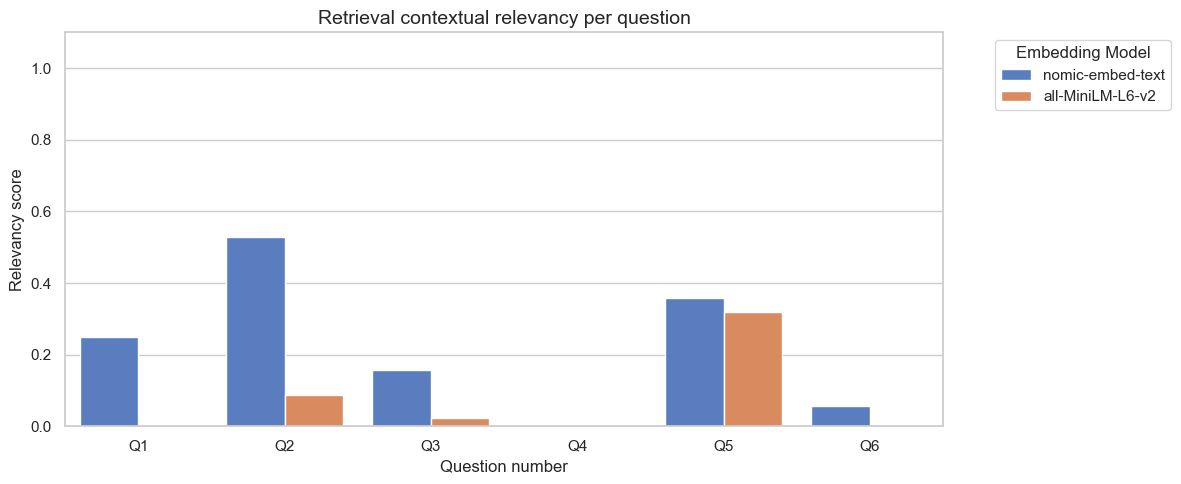

In [5]:
if not df_retrieval.empty:
    retrieval_metrics = []
    for _, row in df_retrieval.iterrows():
        for i, test in enumerate(row['per_test']):
            retrieval_metrics.append({
                'Question number': f"Q{i+1}",
                'Score': test['score'],
                'Model': row['embedding_model']
            })
    
    df_ret_metrics = pd.DataFrame(retrieval_metrics)
    
    plt.figure(figsize=(12, 5))
    sns.barplot(
        data=df_ret_metrics, 
        x='Question number', 
        y='Score', 
        hue='Model',
    )
    plt.title('Retrieval contextual relevancy per question', fontsize=14)
    plt.ylabel('Relevancy score')
    plt.ylim(0, 1.1)
    plt.legend(title='Embedding Model', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

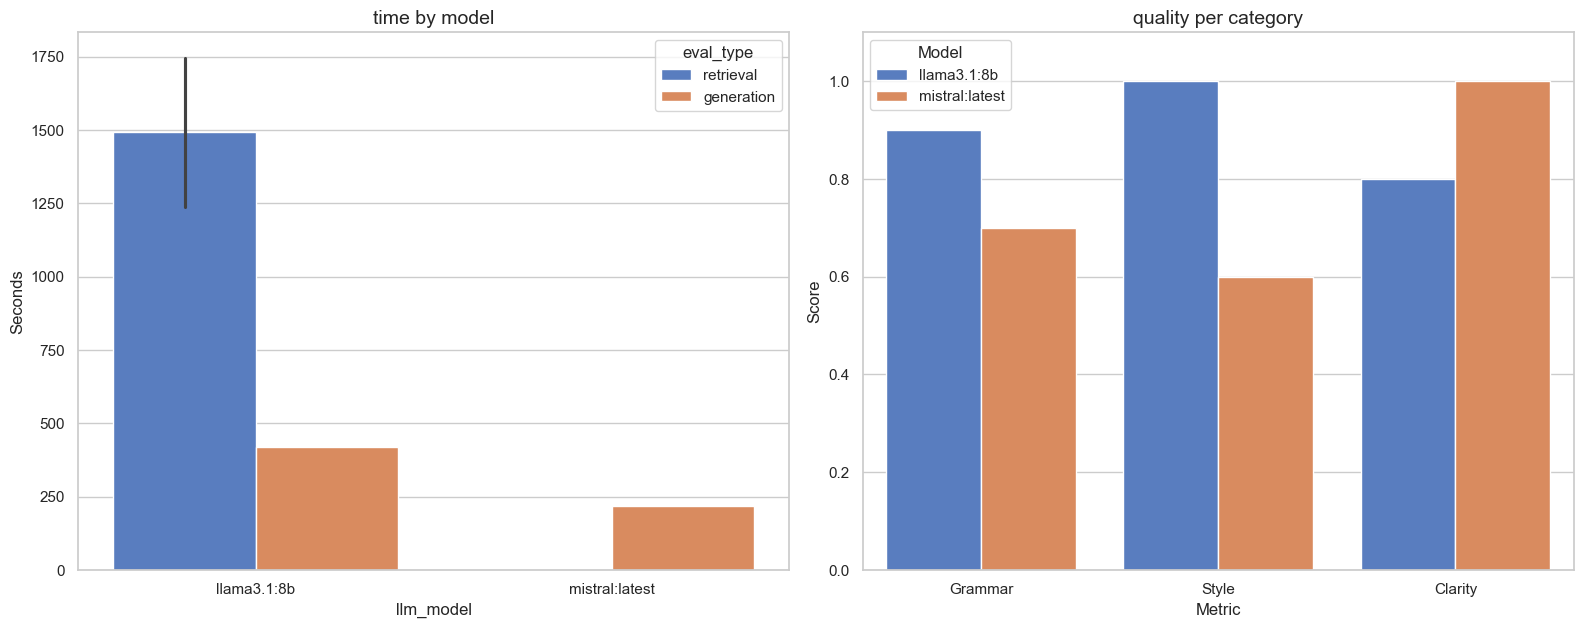

In [6]:
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(2, 2)

ax_bl = fig.add_subplot(gs[1, 0])
sns.barplot(data=df, x='llm_model', y='duration_seconds', hue='eval_type', ax=ax_bl)
ax_bl.set_title('time by model', fontsize=14)
ax_bl.set_ylabel('Seconds')

ax_br = fig.add_subplot(gs[1, 1])
if not df_generation.empty:
    gen_metrics = []
    for _, row in df_generation.iterrows():
        for test in row['per_test']:
            gen_metrics.append({'Model': row['llm_model'], 'Metric': test['metric'].capitalize(), 'Score': test['score']})
    
    sns.barplot(data=pd.DataFrame(gen_metrics), x='Metric', y='Score', hue='Model', ax=ax_br)
    ax_br.set_title('quality per category', fontsize=14)
    ax_br.set_ylim(0, 1.1)

plt.tight_layout()
plt.show()